<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk
import torch.nn.functional as F

from collections import Counter
from typing import List

import seaborn


In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [6]:
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences
for sentence in tqdm(dataset['train']['text']):
    sentences.extend(
        [x.lower() for x in sent_tokenize(sentence) if len(x.split()) < word_threshold]
        )

  0%|          | 0/25000 [00:00<?, ?it/s]

In [7]:
print("Всего предложений:", len(sentences))

Всего предложений: 219930


Посчитаем для каждого слова его встречаемость.

In [8]:
words = Counter()

# Расчет встречаемости слов
for sentence in tqdm(sentences):
    tokens = word_tokenize(sentence.lower())
    for word in tokens:
        words[word] += 1

  0%|          | 0/219930 [00:00<?, ?it/s]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [9]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

# Наполнение словаря
for word, _ in words.most_common(vocab_size):
    vocab.add(word)

In [11]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [12]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [13]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [14]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

        self._is_pre_tokenized = isinstance(sentences[0], list)

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []
        # Допишите код здесь
        tokenized_sentence = [self.bos_id]

        if self._is_pre_tokenized:
            words = self.data[idx]
        else:
            words = self.data[idx].split()

        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in words]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [15]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [16]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [17]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1) # Посчитайте логиты предсказаний следующих слов
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [31]:
def train_model(model, optimizer, criterion, num_epoch=10):
    # Напишите код здесь
    losses = []
    perplexities = []
    try:
      for epoch in range(num_epoch):
          epoch_losses = []
          model.train()
          for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
              optimizer.zero_grad()
              logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
              loss = criterion(
                  logits, batch['target_ids'].flatten())
              loss.backward()
              optimizer.step()

              epoch_losses.append(loss.item())
          epoch_loss = sum(epoch_losses) / len(epoch_losses)
          losses.append(epoch_loss)
          epoch_perplexity = evaluate(model, criterion, eval_dataloader)
          perplexities.append(epoch_perplexity)
          print(f'epoch_loss = {epoch_loss}, epoch_perplexity = {epoch_perplexity}')

    except KeyboardInterrupt:
        print(f"\nTraining interrupted after {len(losses)} epochs")

    return losses, perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [19]:
class CharLM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

In [20]:
# Обучите модель здесь
model = CharLM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [21]:
losses, perplexities = train_model(model, optimizer, criterion, num_epoch=10)

Training epoch 0::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 5.483971823258833, epoch_perplexity = 141.50324040789937


Training epoch 1::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 4.868183977647261, epoch_perplexity = 108.71861360239429


Training epoch 2::   0%|          | 0/1375 [00:00<?, ?it/s]

...

epoch_loss = 4.247739240472967, epoch_perplexity = 71.66808215740114


Training epoch 7::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 4.1759993971044365, epoch_perplexity = 69.15086002349854


Training epoch 8::   0%|          | 0/1375 [00:00<?, ?it/s]

KeyboardInterrupt: 

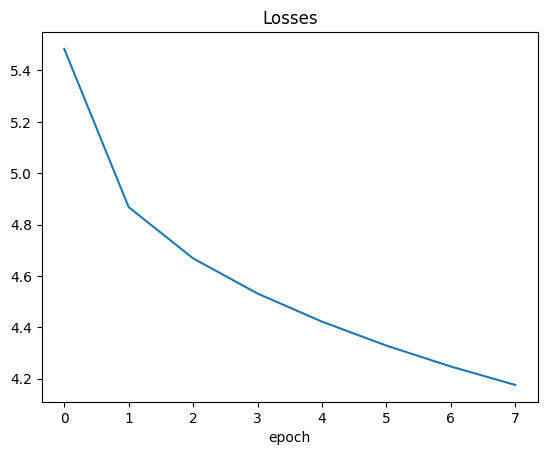

In [24]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

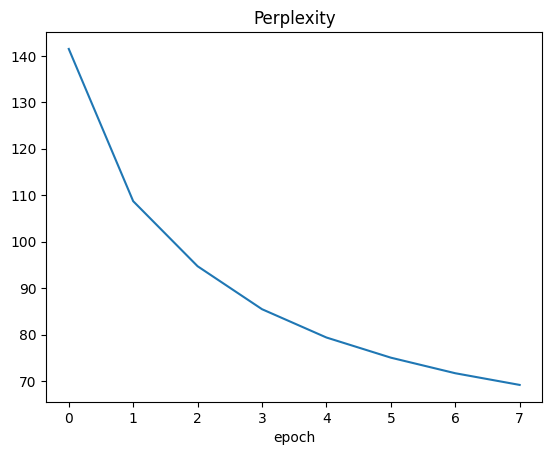

In [25]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [26]:
test_perplexity_1 = evaluate(model, criterion, test_dataloader)

In [27]:
test_perplexity_1

69.11734369411025

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [28]:
# Проведите второй эксперимент
class CharLM_2(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_layers: int = 2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                         batch_first=True, dropout=0.2)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.layer_norm(output)
        output = F.gelu(output)
        output = self.dropout(output)
        projection = self.projection(output)
        return projection

In [29]:
model_2 = CharLM_2(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model_2.parameters(), lr=1e-3)

In [41]:
losses_2, perplexities_2 = train_model(model_2, optimizer, criterion, num_epoch=7)

Training epoch 0::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 5.113343771154231, epoch_perplexity = 116.35834609630496


Training epoch 1::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 4.80799359963157, epoch_perplexity = 96.96997118218


Training epoch 2::   0%|          | 0/1375 [00:00<?, ?it/s]

...

epoch_loss = 4.484494242234663, epoch_perplexity = 74.10108408373456


Training epoch 5::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 4.420527146426114, epoch_perplexity = 70.1442589915076


Training epoch 6::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 4.365548578782515, epoch_perplexity = 66.83377837247626


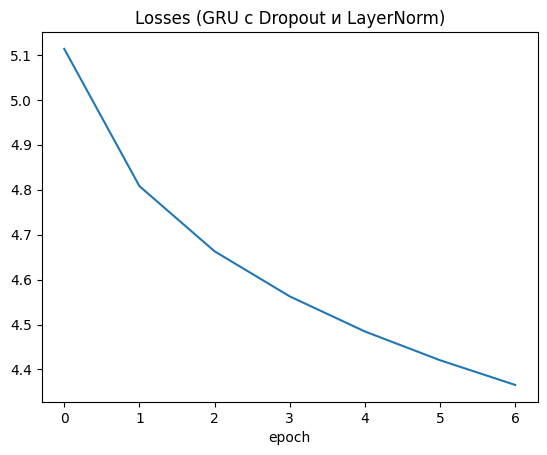

In [42]:
plt.plot(np.arange(len(losses_2)), losses_2)
plt.title('Losses (GRU с Dropout и LayerNorm)')
plt.xlabel("epoch")
plt.show()

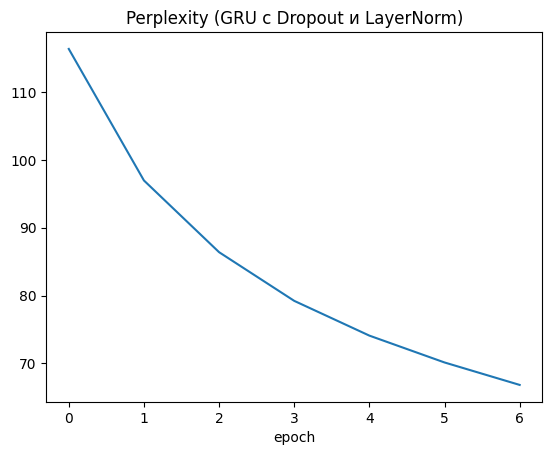

In [43]:
plt.plot(np.arange(len(perplexities_2)), perplexities_2)
plt.title('Perplexity (GRU с Dropout и LayerNorm)')
plt.xlabel("epoch")
plt.show()

In [44]:
test_perplexity_2 = evaluate(model_2, criterion, test_dataloader)

In [45]:
class CharLM_3(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, num_layers: int = 3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.2, bidirectional=False)
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)

        lstm_out, _ = self.lstm(embeddings)
        residual1 = self.layer_norm1(embeddings + lstm_out)

        processed = self.dropout(F.gelu(residual1))
        processed = self.layer_norm2(processed)

        projection = self.projection(processed)
        return projection

In [46]:
model_3 = CharLM_3(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.AdamW(model_3.parameters(), lr=1e-3)

In [47]:
losses_3, perplexities_3 = train_model(model_3, optimizer, criterion, num_epoch=7)

Training epoch 0::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 5.572093102195046, epoch_perplexity = 172.01787734807922


Training epoch 1::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 5.0126692501414905, epoch_perplexity = 124.61981742326603


Training epoch 2::   0%|          | 0/1375 [00:00<?, ?it/s]

...

epoch_loss = 4.549790550578725, epoch_perplexity = 86.442187659685


Training epoch 5::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 4.4766658928611065, epoch_perplexity = 81.17908281725506


Training epoch 6::   0%|          | 0/1375 [00:00<?, ?it/s]

epoch_loss = 4.417078946893866, epoch_perplexity = 77.13750114440919


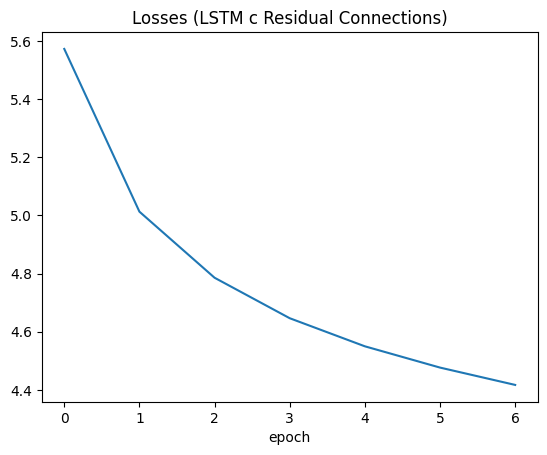

In [48]:
plt.plot(np.arange(len(losses_3)), losses_3)
plt.title('Losses (LSTM с Residual Connections)')
plt.xlabel("epoch")
plt.show()

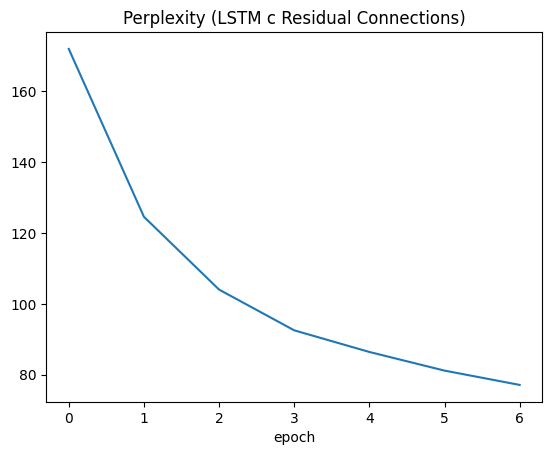

In [49]:
plt.plot(np.arange(len(perplexities_3)), perplexities_3)
plt.title('Perplexity (LSTM с Residual Connections)')
plt.xlabel("epoch")
plt.show()

In [50]:
test_perplexity_3 = evaluate(model_3, criterion, test_dataloader)

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

In [39]:
def generate_sequence(model, starting_seq: str, max_seq_len: int = 30) -> str:
    device = 'cpu'
    model = model.to(device)
    words = starting_seq.split()
    input_ids = [word2ind['<bos>']] + [
        word2ind.get(word, word2ind['<unk>']) for word in words]
    input_ids = torch.LongTensor(input_ids).to(device)

    model.eval()
    with torch.no_grad():
        for i in range(max_seq_len):
            next_char_distribution = model(input_ids)[-1]

            probs = next_char_distribution.squeeze().clone()
            probs[word2ind['<unk>']] = -float('inf')

            next_char = probs.argmax()
            input_ids = torch.cat([input_ids, next_char.unsqueeze(0)])

            if next_char.item() == word2ind['<eos>']:
                break

    words = ' '.join([ind2word[idx.item()] for idx in input_ids])

    return words

In [53]:
text_1 = generate_sequence(model, starting_seq='this film is about ')

In [55]:
text_2 = generate_sequence(model_2, starting_seq='This film is about ')

In [56]:
text_3 = generate_sequence(model_3, starting_seq='This film is about ')

In [58]:
import pandas as pd

results_summary = pd.DataFrame({
    'Модель': ['Базовая модель', 'GRU с Dropout и LayerNorm', 'LSTM с Residual Connections'],
    'Test Perplexity': [test_perplexity_1, test_perplexity_2, test_perplexity_3],
    'Сгенерированный текст': [text_1, text_2, text_3]
})

# results_summary['Длина текста'] = results_summary['Сгенерированный текст'].apply(len)
# results_summary['Кол-во слов'] = results_summary['Сгенерированный текст'].apply(lambda x: len(x.split()))

results_summary = results_summary.sort_values('Test Perplexity')

styled_table = results_summary.style.format({
    'Test Perplexity': '{:.2f}',
    'Длина текста': '{:d}',
    'Кол-во слов': '{:d}'
}).hide(axis='index')

print("СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
print("=" * 80)
styled_table

СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ


Модель,Test Perplexity,Сгенерированный текст
GRU с Dropout и LayerNorm,66.94,film is about a young woman who is a young woman who is a young woman who is a young woman who is a young woman who is a young woman who is
Базовая модель,69.12,this film is about a young boy who is obsessed with his wife and his son and his son are a woman.
LSTM с Residual Connections,77.37,film is about the same time and the rest of the movie is a bit of a good movie.
